In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
# for reproducibility 
np.random.seed(42)
n = 100

--R2 Scores--   | -- Adjusted R2 Scores--

  0.9125        |  0.9116  
  0.9130        |  0.9112  
  0.9126        |  0.9099  
  0.9133        |  0.9097  
  0.9137        |  0.9091  
  0.9146        |  0.9091  
  0.9140        |  0.9074  
  0.9252        |  0.9186  
  0.9148        |  0.9062  
  0.9199        |  0.9109  


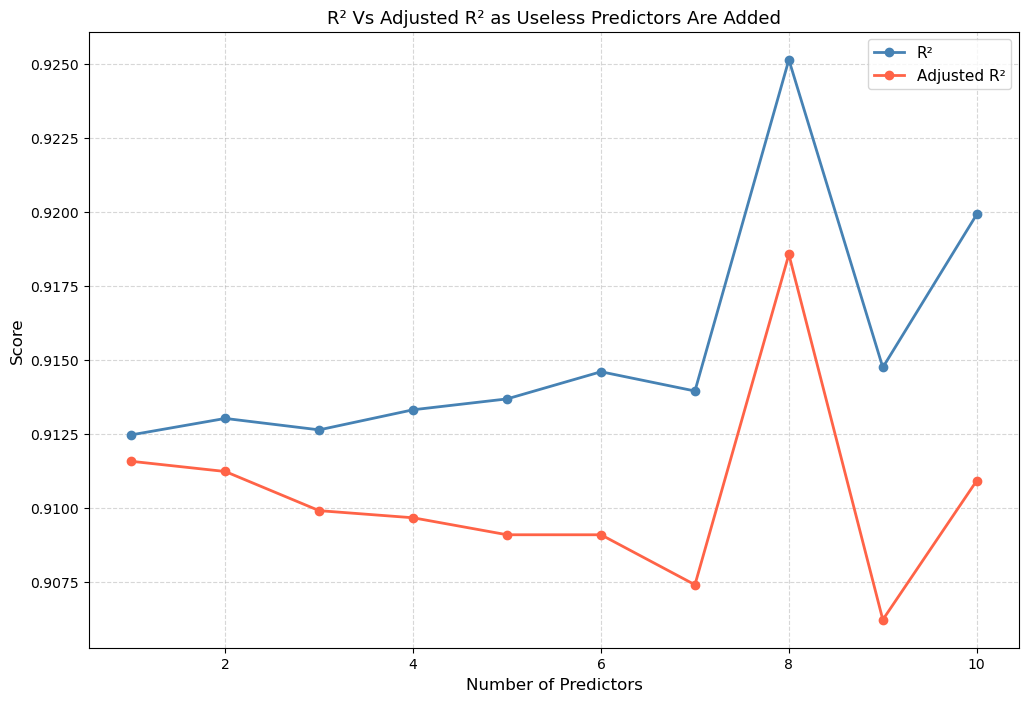

In [83]:
# Actual meaningful variable
# Generates an array of a specified shape and fills it with random floating-point samples drawn from the standard normal distribution
X1 = np.random.randn(n)
y = 3 * X1 + np.random.randn(n)

r2_scores = []
adj_r2_score = []
k_values = list(range(1, 11))

for k in k_values:
    X = np.column_stack([X1] + [np.random.randn(n) for _ in range(k-1)])
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    adj_r2 = 1 - (1 - r2)* (n-1)/(n - k- 1)
    r2_scores.append(r2)
    adj_r2_score.append(adj_r2)

formatted_r2 = [f"{score:.4f}" for score in r2_scores]
formatted_adjr2 = [f"{score:.4f}" for score in adj_r2_score]
print(f"--R2 Scores--   | -- Adjusted R2 Scores--\n")

for item1, item2 in zip(formatted_r2,formatted_adjr2):
    print(f"  {item1}        |  {item2}  ")


plt.figure(figsize = (12, 8))
plt.plot(k_values, r2_scores, marker = "o", label = "R²", color = "steelblue", linewidth =2)
plt.plot(k_values, adj_r2_score, marker = "o", label = "Adjusted R²", color ="tomato", linewidth = 2)

plt.xlabel("Number of Predictors", fontsize = 12)
plt.ylabel("Score", fontsize = 12)
plt.title("R² Vs Adjusted R² as Useless Predictors Are Added", fontsize = 13)
plt.legend(fontsize = 11)
plt.grid(True, linestyle = "--", alpha = 0.5)
